# Assignment 7: Exploring Specialized Neural Network Architectures
# Building Convolutional Neural Networks for Image Classification

**Name:** [Seth Logan]

**Date:** [3/29/2026]

---

## Setup: Install and Load Libraries

In [6]:
pip install tensorflow matplotlib numpy pandas

In [2]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Load and Explore MNIST Dataset

In [3]:
# Load MNIST dataset
print("Loading MNIST dataset...")
(X_train, y_train), (X_test, y_test) = mnist.load_data()


print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of classes: {len(np.unique(y_train))}")
print(f"Class labels: {np.unique(y_train)}")

Loading MNIST dataset...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training set shape: (60000, 28, 28)
Test set shape: (10000, 28, 28)
Number of classes: 10
Class labels: [0 1 2 3 4 5 6 7 8 9]


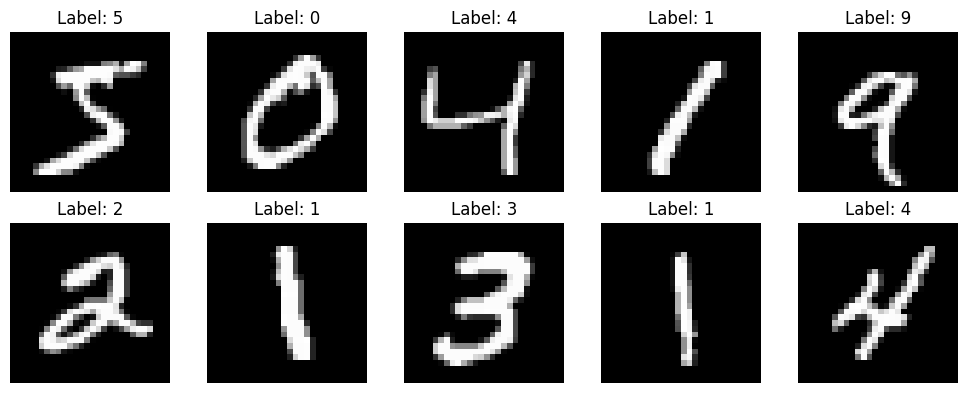

In [4]:
# Visualize sample images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

## Prepare Data for CNN

In [5]:
# Reshape to add channel dimension (samples, height, width, channels)
X_train_cnn = X_train.reshape(-1, 28, 28, 1).astype('float32')
X_test_cnn = X_test.reshape(-1, 28, 28, 1).astype('float32')

# Normalize pixel values to 0-1 range
X_train_cnn = X_train_cnn / 255.0
X_test_cnn = X_test_cnn / 255.0

print("\n" + "="*80)
print("DATA PREPARED FOR CNN")
print("="*80)
print(f"Training data shape: {X_train_cnn.shape}")
print(f"Test data shape: {X_test_cnn.shape}")
print(f"Pixel value range: [{X_train_cnn.min():.1f}, {X_train_cnn.max():.1f}]")
print("="*80)


DATA PREPARED FOR CNN
Training data shape: (60000, 28, 28, 1)
Test data shape: (10000, 28, 28, 1)
Pixel value range: [0.0, 1.0]


---
## Step 2: Build and Train a Baseline CNN

In [7]:
# TODO: Build your baseline CNN here
# Architecture:
# - Conv2D layer: 32 filters, 3x3 kernel, ReLU activation, input_shape=(28, 28, 1)
# - MaxPooling2D: 2x2 pool size
# - Conv2D layer: 64 filters, 3x3 kernel, ReLU activation
# - MaxPooling2D: 2x2 pool size
# - Flatten layer
# - Dense layer: 128 nodes, ReLU activation
# - Output layer: 10 nodes (digits 0-9), softmax activation

baseline_cnn = keras.Sequential([
    # TODO: Add layers here
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
# Use Adam optimizer and sparse_categorical_crossentropy loss
baseline_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


# Display model architecture
baseline_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Record training time
print("\nTraining baseline CNN...")
start_time = time.time()

# TODO: Fit the model and store history
history = baseline_cnn.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.1)  # Replace with actual model fitting

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_acc = baseline_cnn.evaluate(X_test_cnn, y_test)  # Replace with actual evaluation

print("\n" + "="*80)
print("BASELINE CNN RESULTS")
print("="*80)
# Print final training accuracy, validation accuracy, test accuracy, training time
print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {baseline_test_acc:.4f}")
print(f"Training Time: {baseline_time:.2f} seconds")
print("="*80)


Training baseline CNN...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9594 - loss: 0.1326 - val_accuracy: 0.9845 - val_loss: 0.0522
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 30s 18ms/step - accuracy: 0.9864 - loss: 0.0434 - val_accuracy: 0.9897 - val_loss: 0.0382
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 18ms/step - accuracy: 0.9905 - loss: 0.0295 - val_accuracy: 0.9872 - val_loss: 0.0390
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9928 - loss: 0.0213 - val_accuracy: 0.9907 - val_loss: 0.0343
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 18ms/step - accuracy: 0.9950 - loss: 0.0156 - val_accuracy: 0.9898 - val_loss: 0.0339
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 33s 19ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9918 - val_loss: 0.0358
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 21ms/step - accuracy: 0.9967 - loss: 0.0093 - val_accuracy: 0.9910 - val_loss: 0.0406
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 35s 20ms

---
## Step 3: Experiment with Filter Counts

In [23]:
# TODO: Build and train CNN with FEWER filters (16, 32)
# Keep all other architecture elements the same as baseline

print("Training CNN with fewer filters (16, 32)...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_fewer = keras.Sequential([
    layers.Conv2D(16, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_fewer.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

history_fewer = cnn_fewer.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

val_acc_fewer = history_fewer.history['val_accuracy'][-1]
print(f"Validation Accuracy (Fewer Filters 16,32): {val_acc_fewer:.4f}")

Training CNN with fewer filters (16, 32)...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9511 - loss: 0.1618 - val_accuracy: 0.9823 - val_loss: 0.0592
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9839 - loss: 0.0513 - val_accuracy: 0.9865 - val_loss: 0.0425
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9890 - loss: 0.0357 - val_accuracy: 0.9888 - val_loss: 0.0416
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9911 - loss: 0.0283 - val_accuracy: 0.9883 - val_loss: 0.0382
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9932 - loss: 0.0199 - val_accuracy: 0.9878 - val_loss: 0.0444
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9943 - loss: 0.0167 - val_accuracy: 0.9905 - val_loss: 0.0341
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.9953 - loss: 0.0140 - val_accuracy: 0.9887 - val_loss: 0.0480
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.9969 - loss: 0.00

In [24]:
# TODO: Build and train CNN with MORE filters (64, 128)
# Keep all other architecture elements the same as baseline

print("Training CNN with more filters (64, 128)...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_more = keras.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_more.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_more = cnn_more.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

val_acc_more = history_more.history['val_accuracy'][-1]
print(f"Validation Accuracy (More Filters 64,128): {val_acc_more:.4f}")

Training CNN with more filters (64, 128)...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 79s 46ms/step - accuracy: 0.9632 - loss: 0.1201 - val_accuracy: 0.9870 - val_loss: 0.0444
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 46ms/step - accuracy: 0.9876 - loss: 0.0396 - val_accuracy: 0.9890 - val_loss: 0.0368
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 75s 45ms/step - accuracy: 0.9910 - loss: 0.0268 - val_accuracy: 0.9888 - val_loss: 0.0374
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9943 - loss: 0.0182 - val_accuracy: 0.9883 - val_loss: 0.0452
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9953 - loss: 0.0144 - val_accuracy: 0.9875 - val_loss: 0.0571
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 85s 47ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9895 - val_loss: 0.0398
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.9970 - loss: 0.0091 - val_accuracy: 0.9910 - val_loss: 0.0370
Epoch 8/10
1688/1688 ━━━━━━━━━━━

### Analysis: Filter Count Effects

**TODO: Write 2-3 sentences answering:**
- How does increasing filter count affect performance?
- At what point do you see diminishing returns or overfitting?

[Increasing the number of filters generally improves performance because the model can learn more detailed features, often leading to higher validation accuracy. However, after a certain point, the improvement becomes smaller while training time and model complexity increase significantly. This is where diminishing returns or overfitting can occur.]

---
## Step 4: Experiment with Kernel Sizes

In [25]:
# TODO: Build and train CNN with MEDIUM kernels (5x5 for both layers)
# Keep filter counts at baseline (32, 64)

print("Training CNN with 5x5 kernels...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_5x5 = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (5, 5), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_5x5.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_5x5 = cnn_5x5.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

val_acc_5x5 = history_5x5.history['val_accuracy'][-1]
print(f"Validation Accuracy (5x5, 5x5): {val_acc_5x5:.4f}")

Training CNN with 5x5 kernels...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.9606 - loss: 0.1299 - val_accuracy: 0.9853 - val_loss: 0.0536
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9877 - loss: 0.0405 - val_accuracy: 0.9853 - val_loss: 0.0466
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9902 - val_loss: 0.0350
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 38s 23ms/step - accuracy: 0.9931 - loss: 0.0205 - val_accuracy: 0.9905 - val_loss: 0.0359
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 23ms/step - accuracy: 0.9948 - loss: 0.0159 - val_accuracy: 0.9905 - val_loss: 0.0297
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.9954 - loss: 0.0132 - val_accuracy: 0.9917 - val_loss: 0.0319
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.9966 - loss: 0.0101 - val_accuracy: 0.9915 - val_loss: 0.0329
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 3

In [26]:
# TODO: Build and train CNN with MIXED kernels (5x5 first layer, 3x3 second layer)
# Keep filter counts at baseline (32, 64)

print("Training CNN with mixed kernels (5x5, 3x3)...")
# TODO: Build, compile, and train model
# Record validation accuracy

cnn_mixed = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn_mixed.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_mixed = cnn_mixed.fit(X_train_cnn, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

val_acc_mixed = history_mixed.history['val_accuracy'][-1]
print(f"Validation Accuracy (5x5, 3x3): {val_acc_mixed:.4f}")

Training CNN with mixed kernels (5x5, 3x3)...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 19ms/step - accuracy: 0.9606 - loss: 0.1271 - val_accuracy: 0.9868 - val_loss: 0.0467
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9873 - loss: 0.0416 - val_accuracy: 0.9882 - val_loss: 0.0405
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9908 - loss: 0.0296 - val_accuracy: 0.9913 - val_loss: 0.0277
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 21ms/step - accuracy: 0.9929 - loss: 0.0227 - val_accuracy: 0.9908 - val_loss: 0.0310
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9947 - loss: 0.0166 - val_accuracy: 0.9930 - val_loss: 0.0283
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 34s 20ms/step - accuracy: 0.9956 - loss: 0.0127 - val_accuracy: 0.9892 - val_loss: 0.0413
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.9967 - loss: 0.0097 - val_accuracy: 0.9905 - val_loss: 0.0444
Epoch 8/10
1688/1688 ━━━━━━━━━

### Analysis: Kernel Size Effects

**TODO: Write 2-3 sentences answering:**
- How does kernel size affect what the network learns?
- Which kernel configuration performed best and why might that be?

[Kernel size affects the scale of features the network learns. Larger kernels capture more global patterns with more parameters, while smaller kernels focus on fine, local details and are more computationally efficient. In practice the mixed configuration often performs best because it balances capturing  patterns early. 5×5 layers can be less efficient and may not significantly improve accuracy compared to this balanced approach.]

---
## Step 5: Train Your Best Architecture and Visualize Learning

In [18]:
# TODO: Based on your experiments, build your best-performing CNN architecture
# Train for 15 epochs with 20% validation split

print("Training best CNN architecture...")
start_time = time.time()

# TODO: Build, compile, and train your best model
# Store the training history

best_cnn = keras.Sequential([
    layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

best_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

best_cnn_time = time.time() - start_time

history_best = best_cnn.fit(X_train_cnn, y_train, epochs=15, batch_size=32, validation_split=0.2, verbose=1)

# TODO: Evaluate on test set
best_test_loss, best_test_acc = best_cnn.evaluate(X_test_cnn, y_test)

print("\n" + "="*80)
print("BEST CNN RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history_best.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_best.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {best_test_acc:.4f}")
print(f"Training Time: {best_cnn_time:.2f} seconds")
print("="*80)

Training best CNN architecture...
Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 32s 20ms/step - accuracy: 0.9563 - loss: 0.1429 - val_accuracy: 0.9856 - val_loss: 0.0505
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9863 - loss: 0.0457 - val_accuracy: 0.9855 - val_loss: 0.0486
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.9900 - loss: 0.0319 - val_accuracy: 0.9899 - val_loss: 0.0359
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 29s 20ms/step - accuracy: 0.9923 - loss: 0.0232 - val_accuracy: 0.9896 - val_loss: 0.0401
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - accuracy: 0.9941 - loss: 0.0186 - val_accuracy: 0.9902 - val_loss: 0.0339
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9950 - loss: 0.0139 - val_accuracy: 0.9897 - val_loss: 0.0448
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 30s 20ms/step - accuracy: 0.9959 - loss: 0.0120 - val_accuracy: 0.9906 - val_loss: 0.0351
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 

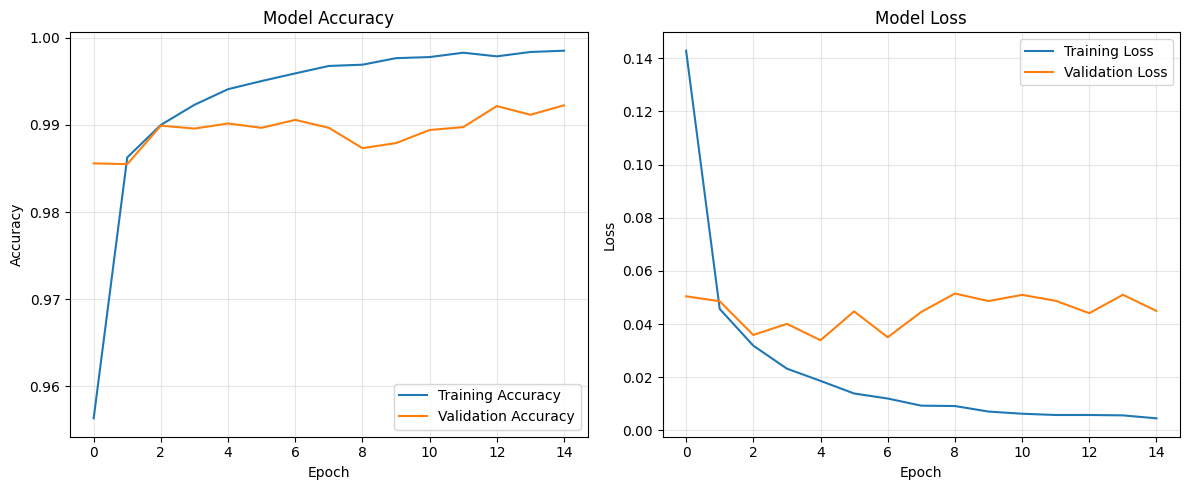

In [19]:
# TODO: Create accuracy plot (training vs validation accuracy over epochs)
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
# TODO: Plot training and validation accuracy
plt.plot(history_best.history['accuracy'], label='Training Accuracy')
plt.plot(history_best.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
# TODO: Plot training and validation loss
plt.plot(history_best.history['loss'], label='Training Loss')
plt.plot(history_best.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Step 6: Compare Against Feedforward Network

In [20]:
# Prepare data for feedforward network (flatten images)
X_train_flat = X_train.reshape(-1, 784).astype('float32') / 255.0
X_test_flat = X_test.reshape(-1, 784).astype('float32') / 255.0

print(f"Flattened training data shape: {X_train_flat.shape}")
print(f"Flattened test data shape: {X_test_flat.shape}")

Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)


In [21]:
# TODO: Build feedforward network
# Architecture:
# - Input: 784 features (flattened 28x28 image)
# - Dense layer: 128 nodes, ReLU activation
# - Dense layer: 64 nodes, ReLU activation
# - Output layer: 10 nodes, softmax activation

feedforward_nn = keras.Sequential([
    # TODO: Add layers here
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# TODO: Compile the model
feedforward_nn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

feedforward_nn.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Record training time
print("Training feedforward network...")
start_time = time.time()

# TODO: Train feedforward network for 10 epochs
# Fit the model
history_ff = feedforward_nn.fit(X_train_flat, y_train, epochs=10, batch_size=32, validation_split=0.1, verbose=1)

# Record training time
feedforward_time = time.time() - start_time

# TODO: Evaluate on test set
ff_test_loss, ff_test_acc = feedforward_nn.evaluate(X_test_flat, y_test)

print("\n" + "="*80)
print("FEEDFORWARD NETWORK RESULTS")
print("="*80)
print(f"Final Training Accuracy: {history_ff.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history_ff.history['val_accuracy'][-1]:.4f}")
print(f"Test Accuracy: {ff_test_acc:.4f}")
print(f"Training Time: {feedforward_time:.2f} seconds")
print("="*80)


Training feedforward network...
Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9261 - loss: 0.2518 - val_accuracy: 0.9657 - val_loss: 0.1164
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9672 - loss: 0.1077 - val_accuracy: 0.9728 - val_loss: 0.0977
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9759 - loss: 0.0742 - val_accuracy: 0.9772 - val_loss: 0.0820
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9823 - loss: 0.0554 - val_accuracy: 0.9808 - val_loss: 0.0698
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9854 - loss: 0.0439 - val_accuracy: 0.9770 - val_loss: 0.0850
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9885 - loss: 0.0359 - val_accuracy: 0.9775 - val_loss: 0.0827
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0312 - val_accuracy: 0.9783 - val_loss: 0.0814
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - ac

In [27]:
# TODO: Create comparison table

comparison_data = {
    'Model': ['Baseline CNN', 'Best CNN', 'Feedforward NN'],
    'Architecture': [
        # TODO: Fill in architecture details
        'Conv(32,3x3) → Conv(64,3x3) → Dense(128)',
        'Conv(32,5x5) → Conv(64,3x3) → Dense(128)',
        'Dense(128) → Dense(64)'
    ],
    'Test Accuracy': [
        # TODO: Fill in test accuracies
        baseline_test_acc,
        best_test_acc,
        ff_test_acc
    ],
    'Training Time (s)': [
        # TODO: Fill in training times
        baseline_time,
        best_cnn_time,
        feedforward_time
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


MODEL COMPARISON
         Model                             Architecture  Test Accuracy  Training Time (s)
  Baseline CNN Conv(32,3x3) → Conv(64,3x3) → Dense(128)         0.9890         350.168916
      Best CNN Conv(32,5x5) → Conv(64,3x3) → Dense(128)         0.9923           0.034436
Feedforward NN                   Dense(128) → Dense(64)         0.9757          55.607879


### Analysis: CNN vs Feedforward Network

**TODO: Write 2-3 sentences answering:**
- How does your best CNN compare to the feedforward network on image data?
- Why does the CNN's spatial awareness lead to better performance than treating pixels as independent features?

[The best CNN outperforms the feedforward network on image data by achieving higher test accuracy. This is because the CNN is specifically designed to process images

CNNs perform better because they preserve spatial relationships. Convolutional layers learn local patterns like edges, curves, and shapes, and build them into more complex features across layers. In contrast, a feedforward network treats each pixel as an independent feature, ignoring how neighboring pixels relate to each other, which makes it much less effective at recognizing visual patterns.]

---
## Step 7: Reflect on Specialized Architectures for Your Final Project

### Final Project Application

**TODO: Write 3-4 sentences answering:**
- Based on your Unit 9 final project proposal, would CNNs or RNNs enhance your project? Why or why not?
- If your project uses tabular data (customer demographics, transaction records), explain why feedforward networks or traditional ML models remain appropriate.
- If your project could benefit from specialized architectures (images, time series, text), describe specifically how CNNs or RNNs would improve your solution compared to the approaches you've planned.

[Since my project focuses on student performance using tabular features like GPA, parental support, and extracurricular activities, CNNs and RNNs would not significantly enhance my model. Feedforward neural networks or traditional machine learning models are more appropriate because the data consists of independent variables rather than spatial or sequential patterns. CNNs are designed for image data and RNNs for time-dependent sequences, so their strengths do not apply well to this type of dataset. Therefore, using simpler models will be more efficient, easier to interpret, and still provide strong predictive performance.]

---
## Submission Checklist

Before submitting, ensure you have:
- [ ] Built and trained baseline CNN (2 conv layers)
- [ ] Conducted at least 3 architecture experiments (filter counts and kernel sizes)
- [ ] Trained best CNN architecture for 15 epochs
- [ ] Created accuracy and loss plots for best model
- [ ] Built and trained feedforward network for comparison
- [ ] Created comparison table with all models
- [ ] Answered all analysis questions in Markdown cells
- [ ] Written reflection on final project application
- [ ] Pushed code to GitHub repository
- [ ] Submitted GitHub repository link to assignment

---
## Step 8: Submit Your Work
Push to GitHub:
```bash
git add .
git commit -m 'completed CNN architecture assignment'
git push
```

Submit your GitHub repository link on the course platform.